# 🧪 5.4 Validación Externa de Modelos: MLP vs CNN vs BiLSTM

Este notebook realiza la validación externa de los mejores checkpoints obtenidos en los experimentos de clasificación con embeddings ProtFlash. El objetivo es evaluar si los modelos **MLP_Small**, **CNN_Small** y **BiLSTM_Medium** generalizan correctamente sobre un conjunto de prueba independiente, más allá de los resultados de validación utilizados durante el entrenamiento.

En esta etapa no se entrenan nuevos pesos: se cargan los modelos finales, se reconstruyen sus arquitecturas y se evalúan con las mismas entradas utilizadas en los notebooks anteriores.

---

## 📋 Descripción general

El conjunto de prueba externo contiene **15,685 muestras**, con una distribución de **4,914 positivas** y **10,771 negativas**, lo que corresponde a una relación aproximada de **0.46**. Cada muestra se representa mediante:

- `X`: embeddings por residuo, con forma `(B, L, 768)`.
- `G`: embedding global/contextual de la secuencia, con forma `(B, 768)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

Durante la evaluación:

1. Se cargan los checkpoints de `MLP_Small`, `CNN_Small` y `BiLSTM_Medium`.
2. Se reconstruyen las arquitecturas correspondientes:
   - `MeanMLPClassifier`
   - `MeanConv1DClassifier`
   - `MeanBiLSTMClassifier`
3. Cada modelo procesa `X`, `G` y `M` para generar probabilidades de clasificación.
4. Se aplica un umbral de `0.5` y se calculan las métricas finales sobre el conjunto externo.

---

## 🛠️ Funcionalidades principales

1. **Carga y reconstrucción de modelos**
   - Importación de los checkpoints finales:
     - `MLP_Small`: `mean_mlp_best_model_final.pth`
     - `CNN_Small`: `best_model_final.pth`
     - `BiLSTM_Medium`: `best_model_final.pth`
   - Reconstrucción de cada arquitectura usando la configuración guardada en el checkpoint.

2. **Evaluación externa**
   - Inferencia sobre `test_dataset.pt` sin reentrenamiento.
   - Uso de `masked_mean_pool` para agregar los embeddings por residuo respetando la máscara.
   - Cálculo de:
     - Accuracy
     - Precision
     - Recall
     - F1-score
     - MCC
     - ROC-AUC
     - PR-AUC
     - Matriz de confusión

3. **Comparación de generalización**
   - Ranking de modelos por **Test MCC**.
   - Comparación entre métricas de validación y métricas de test.
   - Cálculo de brechas de rendimiento:
     - Δ Accuracy
     - Δ F1
     - Δ MCC
     - Δ ROC-AUC
   - Exportación del análisis en `val_vs_test_gap.csv`.

4. **Visualización y exportación**
   - Gráficos de barras comparativos.
   - Curvas ROC.
   - Curvas de precisión-recall.
   - Matrices de confusión.
   - Gráfico de radar multidimensional.
   - Exportación de resultados en CSV y JSON dentro de `Validation_Results/`.

## 📦 Importación de librerías y entorno

In [1]:
import os
import json
import random
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, roc_curve, precision_recall_curve, auc,
    confusion_matrix
)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

print("torch:", torch.__version__)

torch: 2.10.0+cu128


## ⚙️ Configuración de rutas e hiperparámetros de evaluación

In [2]:
MLP_DIR = Path("/kaggle/input/datasets/user/otro-mean-mlp")
CNN_DIR = Path("/kaggle/input/datasets/user/otro-mean-cnn")
LSTM_DIR = Path("/kaggle/input/datasets/user/otro-mean-lstm")

EVAL_DIR = Path("/kaggle/working/Validation_Results")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TEST = Path("/kaggle/input/datasets/user/new-final-dataset/test_dataset.pt")

# Checkpoints a evaluar
CHECKPOINTS = {
    "MLP_Small":    MLP_DIR / "mean_mlp_best_model_final.pth",
    "CNN_Small":   CNN_DIR / "best_model_final.pth",
    "BiLSTM_Medium": LSTM_DIR / "best_model_final.pth",
}

SEED        = 31
BATCH_SIZE  = 32
L_MAX       = 100
INPUT_DIM   = 768      
THRESHOLD = 0.5

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Mean Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de prueba

In [6]:
print("Loading test dataset:")
test_ds = load_pt_dataset(TEST)

pos = int(test_ds.y.sum().item())
neg = test_ds.y.shape[0] - pos
total = test_ds.y.shape[0]
print(f"Test set: total={len(test_ds.y)}, pos={pos}, neg={neg}, pos_ratio={pos/len(test_ds.y):.3f}")

Loading test dataset:
Test set: total=15685, pos=4914, neg=10771, pos_ratio=0.313


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoader

In [8]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"✅ Dataset listo: {len(test_ds)} muestras")
first_item = test_ds[0]
print(f"   Ejemplo de un item: {[v.shape if isinstance(v, torch.Tensor) else type(v).__name__ for v in first_item.values()]}")

X_b, G_b, M_b, y_b = next(iter(test_loader))
print(f"\n   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)} | M_b: {tuple(M_b.shape)} | y_b: {tuple(y_b.shape)}")

✅ Dataset listo: 15685 muestras
   Ejemplo de un item: [torch.Size([100, 768]), torch.Size([768]), torch.Size([100]), torch.Size([1])]

   ✅ X_b: (32, 100, 768) | G_b: (32, 768) | M_b: (32, 100) | y_b: (32, 1)


## 🔑 Mecanismo MaskedMeanPool

In [9]:
class masked_mean_pool(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.input_dim = input_dim

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, D)
        M: (B, L)
        """
        mask = M.unsqueeze(-1)  # (B, L, 1)
        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)
        return (X * mask).sum(dim=1) / denom

## 🧩 Definición de arquitecturas para reconstrucción de checkpoints

In [10]:
# --- MLP Classifier ---
class MeanMLPClassifier(nn.Module):

    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float = 0.3):
        super().__init__()

        self.pooler = masked_mean_pool(input_dim=input_dim)

        layers = []
        in_features = input_dim * 2

        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        E = self.pooler(X, M)            # (B, D)
        combined = torch.cat([E, G], dim=1)  # (B, 2D)
        x = self.mlp_body(combined)
        return self.classifier(x)


def build_mean_mlp_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanMLPClassifier(input_dim, config["hidden_dims"], config["dropout"])

# --- CNN Classifier ---
class MeanConv1DClassifier(nn.Module):
    """1D-CNN classifier con Mean Pooling."""

    def __init__(self, input_dim: int, conv_channels: List[int],
                 kernel_sizes: List[int], mlp_hidden: List[int],
                 dropout: float = 0.3):
        super().__init__()

        # ✅ Mean Pooling
        self.pooler = masked_mean_pool(input_dim=input_dim)

        self.convs = nn.ModuleList()
        in_channels = input_dim
        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=k_size, padding="same"),
                nn.BatchNorm1d(out_channels),
                nn.GELU(),
                nn.Dropout1d(dropout),
            ))
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        # ✅ clf_in_dim = CNN + Global + MeanPooled
        clf_in_dim = cnn_out_dim + input_dim + input_dim

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # Mean pooling global
        E = self.pooler(X, M)  # (B, D)

        # CNN
        x_cnn = X.transpose(1, 2)  # (B, D, L)
        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        combined = torch.cat([cnn_features, G, E], dim=1)
        x = self.mlp(combined)
        return self.classifier(x)


def build_mean_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanConv1DClassifier(
        input_dim, config["conv_channels"], config["kernel_sizes"],
        config["mlp_hidden"], config["dropout"],
    )

# --- LSTM Classifier ---
class MeanBiLSTMClassifier(nn.Module):
    """BiLSTM classifier con Mean Pooling (sin gating por residuo)."""

    def __init__(self, input_dim: int, hidden_size: int, num_layers: int,
                 mlp_hidden: List[int], dropout: float = 0.3):
        super().__init__()

        self.pooler = masked_mean_pool(input_dim=input_dim)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # lstm_out_dim = hidden_size * 4 (max_pool + avg_pool de forward/backward)
        lstm_out_dim = hidden_size * 4
        clf_in_dim = lstm_out_dim + input_dim  # + G global

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(X, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=X.size(1))

        # Pooling sobre salida del LSTM
        mask = M.unsqueeze(-1).bool()
        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]
        avg_pool = (lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
                    / M.sum(dim=1, keepdim=True).clamp(min=1e-8))

        lstm_features = torch.cat([max_pool, avg_pool], dim=1)

        combined = torch.cat([lstm_features, G], dim=1)
        x = self.mlp(combined)
        return self.classifier(x)


def build_mean_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanBiLSTMClassifier(
        input_dim, config["hidden_size"], config["num_layers"],
        config["mlp_hidden"], config["dropout"],
    )

## 📥 Carga segura de checkpoints y verificación de metadatos

In [11]:
def load_model(path, model_class, device, input_dim):
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    config = ckpt["config"]
    input_dim = ckpt.get("input_dim", input_dim)

    if model_class == MeanMLPClassifier:
        model = MeanMLPClassifier(
            input_dim=input_dim,
            hidden_dims=config["hidden_dims"],
            dropout=config.get("dropout", 0.3),
        )

    elif model_class == MeanConv1DClassifier:
        model = MeanConv1DClassifier(
            input_dim=input_dim,
            conv_channels=config["conv_channels"],
            kernel_sizes=config["kernel_sizes"],
            mlp_hidden=config["mlp_hidden"],
            dropout=config.get("dropout", 0.3),
        )

    elif model_class == MeanBiLSTMClassifier:
        model = MeanBiLSTMClassifier(
            input_dim=input_dim,
            hidden_size=config["hidden_size"],       # ✅ era hidden_size, no hidden_dim
            num_layers=config["num_layers"],
            mlp_hidden=config["mlp_hidden"],
            dropout=config.get("dropout", 0.3),
        )

    else:
        raise ValueError(f"Clase de modelo no reconocida: {model_class}")

    model.load_state_dict(ckpt["state_dict"])
    return model.to(device).eval()

print("Cargando checkpoints...")
model_mlp = load_model(CHECKPOINTS["MLP_Small"], MeanMLPClassifier, DEVICE, INPUT_DIM)
model_cnn  = load_model(CHECKPOINTS["CNN_Small"],  MeanConv1DClassifier, DEVICE, INPUT_DIM)
model_bilstm = load_model(CHECKPOINTS["BiLSTM_Medium"], MeanBiLSTMClassifier, DEVICE, INPUT_DIM)
print("✅ Modelos cargados exitosamente.")

Cargando checkpoints...
✅ Modelos cargados exitosamente.


## 📐 Helper: `sigmoid_np`

In [12]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [13]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    logits_list, y_list = [], []
    for Xb, Gb, Mb, yb in loader:
        logits = model(Xb.to(device), Gb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    logits_all = np.concatenate(logits_list)
    y_all = np.concatenate(y_list)
    return sigmoid_np(logits_all), y_all

## 📏 Cálculo de Métricas de Clasificación

In [14]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

## 🔄 Loops de Evaluación

In [15]:
all_eval: List[Dict[str, Any]] = []

print("\n" + "=" * 90)
print("EVALUATING MEAN MODELS ON TEST SET")
print("=" * 90)

for model_name, ckpt_path in CHECKPOINTS.items():
    print(f"\n{'─' * 80}")

    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)

    config = ckpt["config"]
    input_dim = ckpt["input_dim"]
    
    # 1. Recuperar info si existe
    best_epoch = ckpt.get('best_epoch', "Unknown")
    best_val_loss = ckpt.get('best_val_loss', "Unknown")
    
    # Extraer métricas de validación del checkpoint
    val_metrics_from_ckpt = ckpt.get("val_metrics", {}) 

    # Build & load model
    if "MLP" in model_name:
        model = build_mean_mlp_model(config, input_dim)
    elif "CNN" in model_name or "Conv" in model_name:
        model = build_mean_cnn_model(config, input_dim)
    else:
        model = build_mean_lstm_model(config, input_dim)

    # Cargar los pesos y mandarlo a GPU
    model.load_state_dict(ckpt["state_dict"])
    model.to(DEVICE)
    model.eval()

    # 2. CALCULAR LOS PARÁMETROS REALES DEL MODELO VOLCADO EN RAM
    n_params = sum(p.numel() for p in model.parameters())

    print(f"Model: {model_name}")
    print(f"  Parameters: {n_params:,}")  # Ahora sí tendrá un número, ejemplo: 2,543,123
    print(f"  Best training epoch: {best_epoch}")
    print(f"  Best val loss: {best_val_loss}")

    # Predict on test
    y_prob, y_true = predict_proba(model, test_loader, DEVICE)
    metrics = compute_metrics (y_true, y_prob)

    # Curvas
    fpr, tpr, _ = roc_curve(y_true.astype(int), y_prob)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true.astype(int), y_prob)

    entry = {
        "name": model_name,
        "config": config,
        "n_params": n_params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_metrics": metrics,
        "val_metrics": val_metrics_from_ckpt,
        "y_prob": y_prob,
        "y_true": y_true,
        "fpr": fpr,
        "tpr": tpr,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
    }

    cm = confusion_matrix(y_true.astype(int), (y_prob >= THRESHOLD).astype(int), labels=[0, 1])
    entry["test_metrics"]["confusion_matrix"] = {"tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1])}
    
    all_eval.append(entry)

    print(f"  ✅ Test Acc={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f} | "
          f"MCC={metrics['mcc']:.4f} | AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f}")

print(f"\n{'=' * 90}")
print(f"Evaluated {len(all_eval)} mean models on test")
print("=" * 90)


EVALUATING MEAN MODELS ON TEST SET

────────────────────────────────────────────────────────────────────────────────
Model: MLP_Small
  Parameters: 427,265
  Best training epoch: 7
  Best val loss: 0.049556868685077325
  ✅ Test Acc=0.9005 | F1=0.8474 | MCC=0.7751 | AUC=0.9505 | PR-AUC=0.9331

────────────────────────────────────────────────────────────────────────────────
Model: CNN_Small
  Parameters: 549,953
  Best training epoch: 5
  Best val loss: 0.0473239251174206
  ✅ Test Acc=0.9068 | F1=0.8584 | MCC=0.7911 | AUC=0.9600 | PR-AUC=0.9390

────────────────────────────────────────────────────────────────────────────────
Model: BiLSTM_Medium
  Parameters: 3,908,097
  Best training epoch: 4
  Best val loss: 0.04733750024853751
  ✅ Test Acc=0.9048 | F1=0.8556 | MCC=0.7870 | AUC=0.9581 | PR-AUC=0.9346

Evaluated 3 mean models on test


## 📊 Tabla Resumen y Ranking de Modelos

In [16]:
rows = []
for r in all_eval:
    m = r["test_metrics"]
    vm = r.get("val_metrics", {})
    
    rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Train Epoch": r.get("best_epoch", "N/A"),
        "Val Loss": r.get("best_val_loss", "N/A"),
        "Val Acc": vm.get("accuracy"),
        "Val F1": vm.get("f1"),
        "Test Acc": m["accuracy"],
        "Test Prec": m.get("precision", 0),
        "Test Recall": m.get("recall", 0),
        "Test F1": m["f1"],
        "Test MCC": m["mcc"],
        "Test ROC-AUC": m["roc_auc"],
        "Test PR-AUC": m["pr_auc"],
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Test MCC", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

print("\n" + "=" * 120)
print("TEST SET — MEAN MODEL COMPARISON (sorted by Test MCC)")
print("=" * 120)
print(results_df.to_string())
print("=" * 120)

csv_path = EVAL_DIR / "test_comparison_table.csv"
results_df.to_csv(csv_path)

best_name = results_df.iloc[0]["Model"]
best_entry = next(r for r in all_eval if r["name"] == best_name)
print(f"\n🏆 Best mean model on test: {best_name}")


TEST SET — MEAN MODEL COMPARISON (sorted by Test MCC)
              Model   Params  Train Epoch  Val Loss   Val Acc    Val F1  Test Acc  Test Prec  Test Recall   Test F1  Test MCC  Test ROC-AUC  Test PR-AUC
Rank                                                                                                                                                    
1         CNN_Small   549953            5  0.047324  0.901405  0.890621  0.906790   0.819157     0.901506  0.858361  0.791148      0.959969     0.938959
2     BiLSTM_Medium  3908097            4  0.047338  0.903585  0.891671  0.904814   0.815183     0.900285  0.855623  0.787039      0.958078     0.934568
3         MLP_Small   427265            7  0.049557  0.901890  0.889856  0.900478   0.815309     0.882173  0.847424  0.775073      0.950522     0.933128

🏆 Best mean model on test: CNN_Small


## 🔍 Análisis de gap: Validación vs Test

In [17]:
print("\n" + "=" * 100)
print("VALIDATION vs TEST — PERFORMANCE GAP")
print("=" * 100)

gap_rows = []
for r in all_eval:
    vm = r.get("val_metrics", {})
    tm = r["test_metrics"]
    gap_rows.append({
        "Model": r["name"],
        "Val Acc": vm.get("accuracy"),
        "Test Acc": tm["accuracy"],
        "Δ Acc": (tm["accuracy"] - vm.get("accuracy", 0)) if vm.get("accuracy") is not None else None,
        "Val F1": vm.get("f1"),
        "Test F1": tm["f1"],
        "Δ F1": (tm["f1"] - vm.get("f1", 0)) if vm.get("f1") is not None else None,
        "Val MCC": vm.get("mcc"),
        "Test MCC": tm["mcc"],
        "Δ MCC": (tm["mcc"] - vm.get("mcc", 0)) if vm.get("mcc") is not None else None,
        "Val AUC": vm.get("roc_auc"),
        "Test AUC": tm["roc_auc"],
        "Δ AUC": (tm["roc_auc"] - vm.get("roc_auc", 0)) if vm.get("roc_auc") is not None else None,
    })

gap_df = pd.DataFrame(gap_rows)
print(gap_df.to_string(index=False))

gap_csv = EVAL_DIR / "val_vs_test_gap.csv"
gap_df.to_csv(gap_csv, index=False)


VALIDATION vs TEST — PERFORMANCE GAP
        Model  Val Acc  Test Acc     Δ Acc   Val F1  Test F1      Δ F1  Val MCC  Test MCC     Δ MCC  Val AUC  Test AUC     Δ AUC
    MLP_Small 0.901890  0.900478 -0.001411 0.889856 0.847424 -0.042431 0.805788  0.775073 -0.030715 0.958447  0.950522 -0.007925
    CNN_Small 0.901405  0.906790  0.005385 0.890621 0.858361 -0.032260 0.803532  0.791148 -0.012384 0.960573  0.959969 -0.000604
BiLSTM_Medium 0.903585  0.904814  0.001228 0.891671 0.855623 -0.036048 0.809332  0.787039 -0.022292 0.959936  0.958078 -0.001857


## 📈 Visualización: Gráfico de barras comparativo por métrica

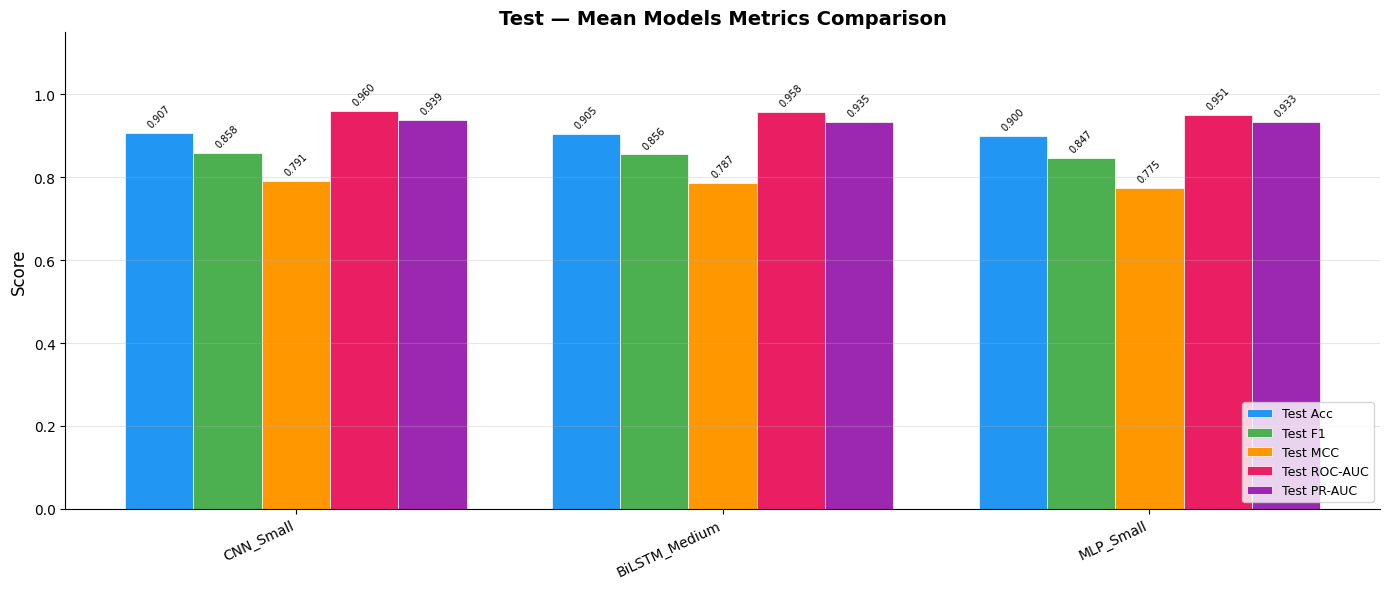

In [18]:
metric_cols = ["Test Acc", "Test F1", "Test MCC", "Test ROC-AUC", "Test PR-AUC"]
models = results_df["Model"].values

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(models))
n_metrics = len(metric_cols)
width = 0.8 / n_metrics
colors_bar = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"]

for j, (col, color) in enumerate(zip(metric_cols, colors_bar)):
    vals = results_df[col].values.astype(float)
    bars = ax.bar(x + j * width, vals, width, label=col, color=color, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x + width * (n_metrics - 1) / 2)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test — Mean Models Metrics Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(EVAL_DIR / "test_metrics_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()

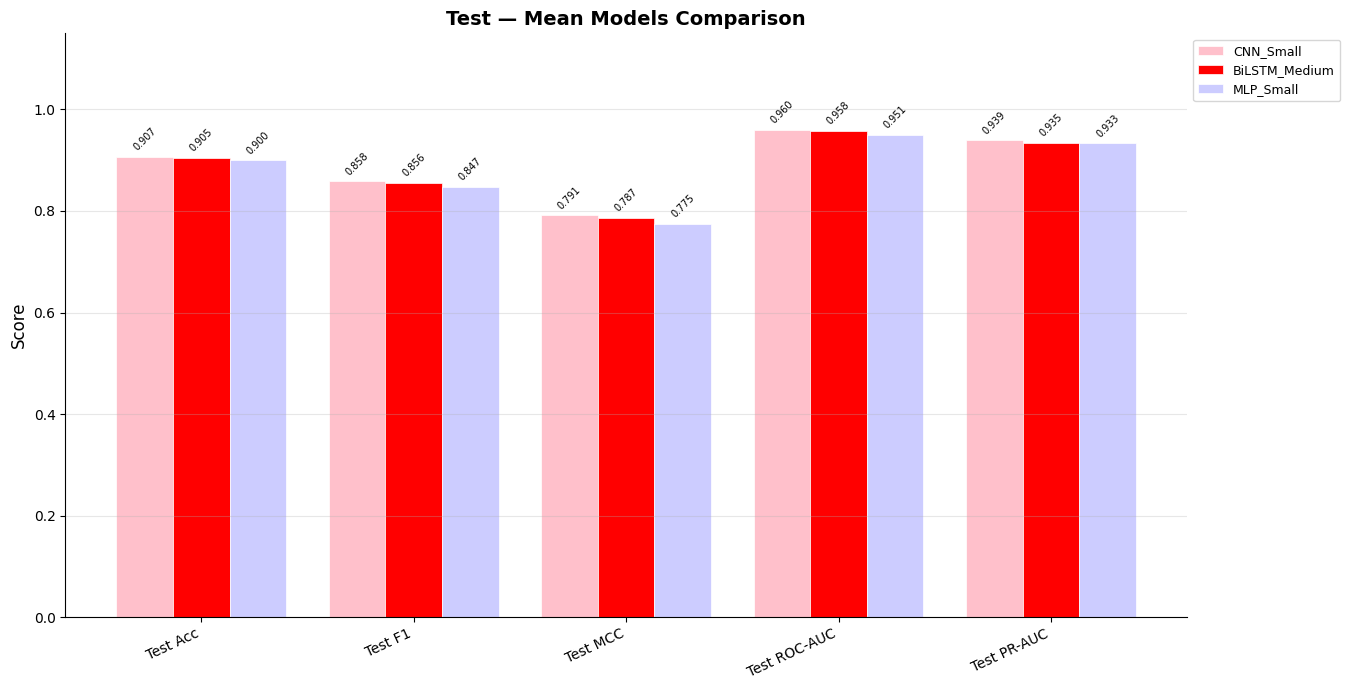

In [19]:
metric_cols_plot = ["Test Acc", "Test F1", "Test MCC", "Test ROC-AUC", "Test PR-AUC"]
model_names = results_df["Model"].values

fig, ax = plt.subplots(figsize=(16, 7))
x_pos_metrics = np.arange(len(metric_cols_plot))
n_models = len(model_names)
width = 0.8 / n_models
colors_model = ["#FFC0CB", "#FF0000", "#CCCCFF"]

for i, model_name in enumerate(model_names):
    vals = results_df[results_df["Model"] == model_name][metric_cols_plot].values.flatten().astype(float)
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x_pos_metrics + offset, vals, width,
                  label=model_name, color=colors_model[i % len(colors_model)], edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x_pos_metrics)
ax.set_xticklabels(metric_cols_plot, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test — Mean Models Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1,1), fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(rect=[0, 0, 0.85, 1])
fig.savefig(EVAL_DIR / "test_metrics_bar_chart_transposed.png", dpi=200, bbox_inches="tight")
plt.show()

## 📈 Visualización: Curvas ROC

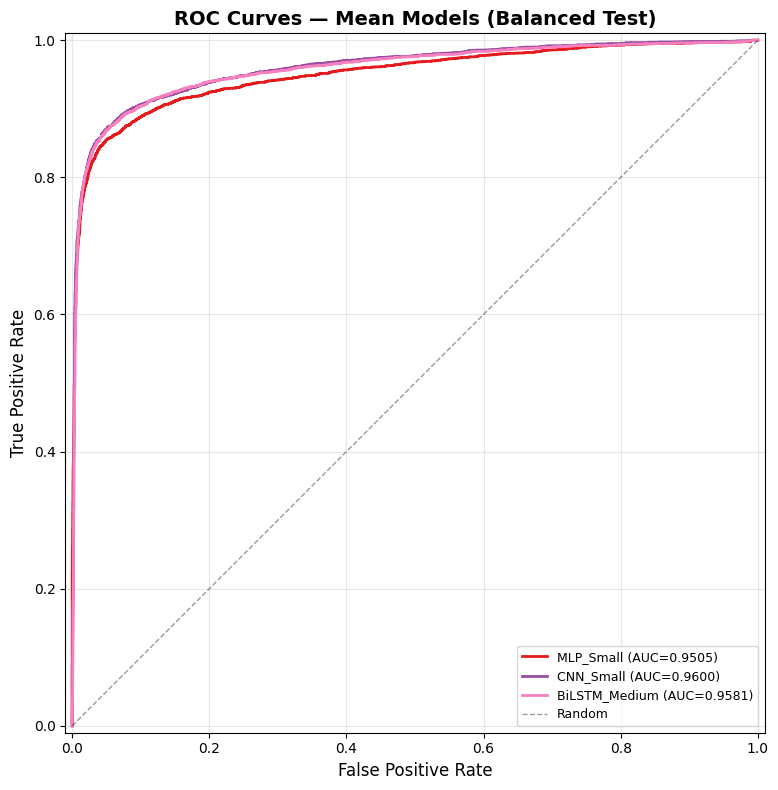

In [20]:
# ========== CURVAS ROC ==========
fig, ax = plt.subplots(figsize=(8, 8))
colors_line = plt.cm.Set1(np.linspace(0, 0.8, len(all_eval)))

for idx, r in enumerate(all_eval):
    auc_val = r["test_metrics"]["roc_auc"]
    ax.plot(r["fpr"], r["tpr"],
            label=f"{r['name']} (AUC={auc_val:.4f})",
            color=colors_line[idx], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Mean Models (Balanced Test)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "roc_curves_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 🔲 Visualización: Matrices de confusión

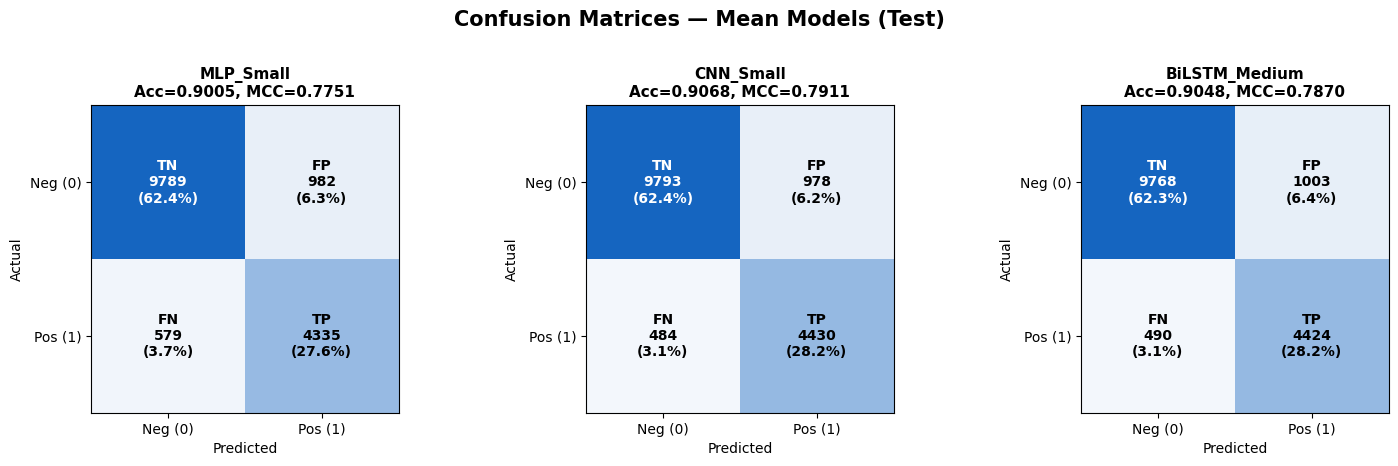

In [21]:
n_models = len(all_eval)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)
cmap_cm = LinearSegmentedColormap.from_list("custom_blue", ["#ffffff", "#1565C0"])

for idx, r in enumerate(all_eval):
    row_i, col_i = divmod(idx, n_cols)
    ax = axes[row_i][col_i]
    cm_data = r["test_metrics"]["confusion_matrix"]
    cm = np.array([[cm_data["tn"], cm_data["fp"]],
                   [cm_data["fn"], cm_data["tp"]]])
    total = cm.sum()
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap_cm, vmin=0, vmax=cm.max())
    labels_text = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / total * 100
            color = "white" if val > cm.max() * 0.6 else "black"
            ax.text(j, i, f"{labels_text[i][j]}\n{val}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=10, color=color, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg (0)", "Pos (1)"])
    ax.set_yticklabels(["Neg (0)", "Pos (1)"])
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    acc = r["test_metrics"]["accuracy"]
    mcc = r["test_metrics"]["mcc"]
    ax.set_title(f"{r['name']}\nAcc={acc:.4f}, MCC={mcc:.4f}", fontsize=11, fontweight="bold")

for idx in range(n_models, n_rows * n_cols):
    row_i, col_i = divmod(idx, n_cols)
    axes[row_i][col_i].set_visible(False)

fig.suptitle("Confusion Matrices — Mean Models (Test)", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

## 🎯 Visualización: Gráfico de radar multidimensional

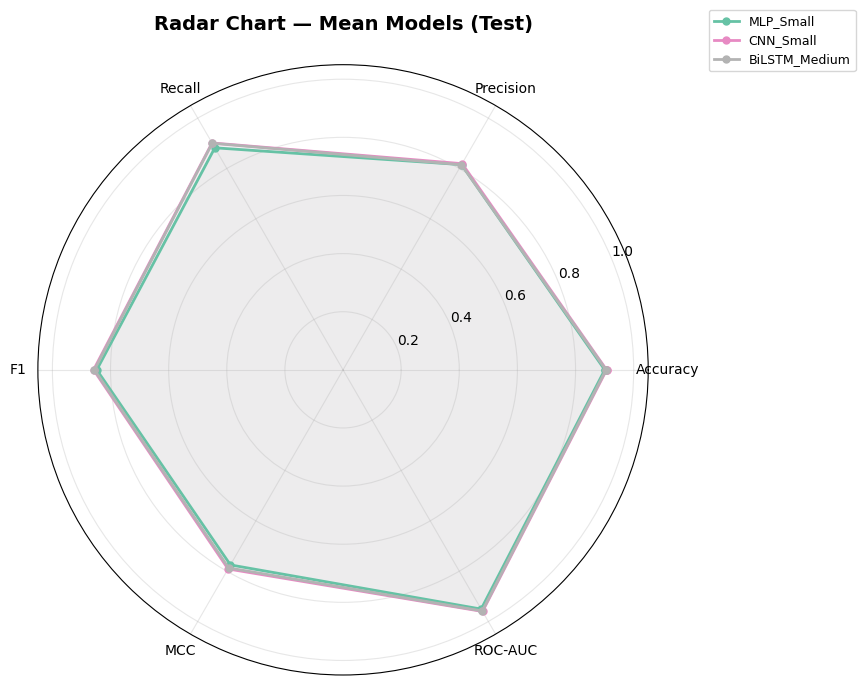

In [22]:
radar_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "roc_auc"]
radar_labels = ["Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
colors_radar = plt.cm.Set2(np.linspace(0, 0.9, len(all_eval)))

for idx, r in enumerate(all_eval):
    values = [r["test_metrics"].get(m, 0) or 0 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=r["name"], color=colors_radar[idx], markersize=5)
    ax.fill(angles, values, alpha=0.08, color=colors_radar[idx])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Radar Chart — Mean Models (Test)", fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 📊 Visualización: Gráfico de Barras Comparativo (Validación vs Prueba)

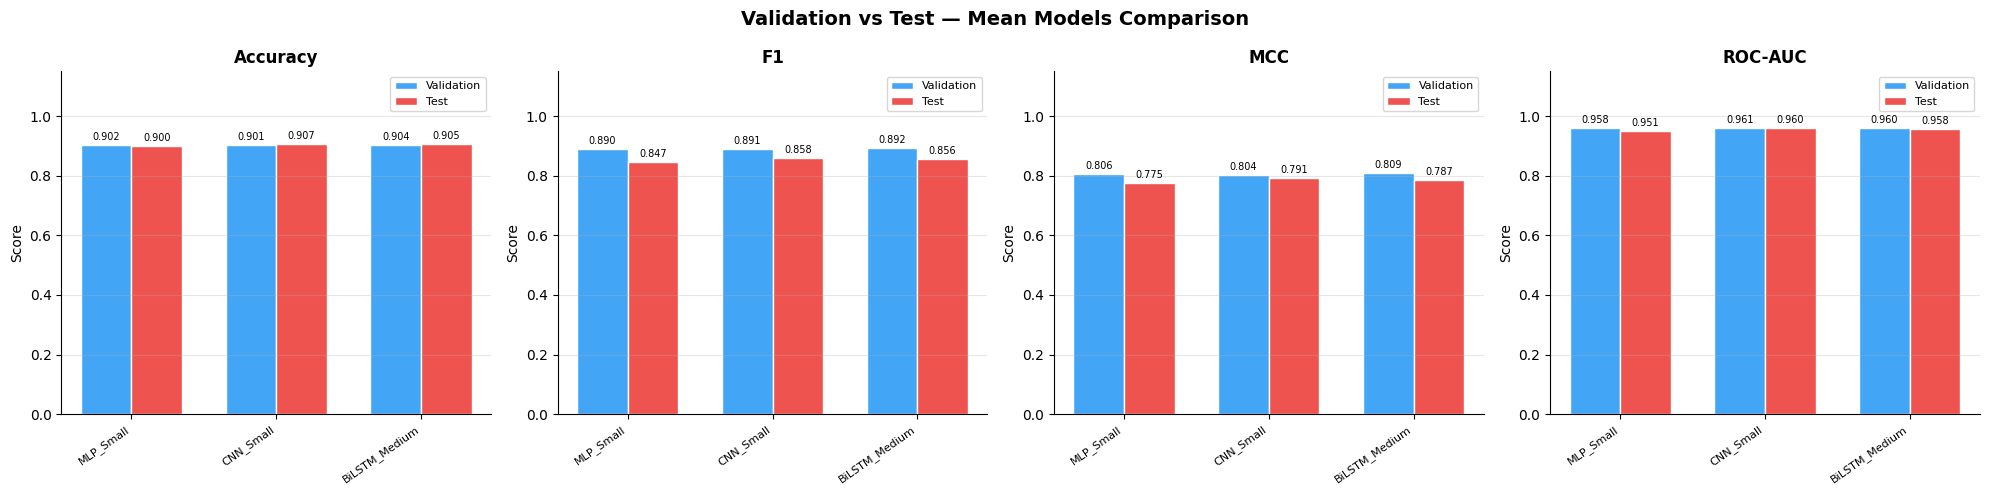

In [23]:
val_test_metrics = ["accuracy", "f1", "mcc", "roc_auc"]
val_test_labels  = ["Accuracy", "F1", "MCC", "ROC-AUC"]

fig, axes = plt.subplots(1, len(val_test_metrics), figsize=(5 * len(val_test_metrics), 5))
model_names = [r["name"] for r in all_eval]
x = np.arange(len(model_names))
width_vt = 0.35

for ax_idx, (metric_key, metric_label) in enumerate(zip(val_test_metrics, val_test_labels)):
    ax = axes[ax_idx]
    val_vals = []
    test_vals = []
    for r in all_eval:
        vm = r.get("val_metrics", {})
        tm = r["test_metrics"]
        val_vals.append(vm.get(metric_key, 0) or 0)
        test_vals.append(tm.get(metric_key, 0) or 0)

    bars1 = ax.bar(x - width_vt / 2, val_vals, width_vt, label="Validation", color="#42A5F5", edgecolor="white")
    bars2 = ax.bar(x + width_vt / 2, test_vals, width_vt, label="Test", color="#EF5350", edgecolor="white")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title(metric_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Validation vs Test — Mean Models Comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(EVAL_DIR / "val_vs_test_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 💾 Guardado de resultados para reproducibilidad

In [24]:
all_metrics_json = {}
for r in all_eval:
    all_metrics_json[r["name"]] = {
        "config": r["config"],
        "n_params": r["n_params"],
        "best_train_epoch": r["best_epoch"],
        "best_val_loss": r["best_val_loss"],
        "val_metrics": r.get("val_metrics", {}),
        "test_metrics": {k: v for k, v in r["test_metrics"].items() if k != "confusion_matrix"},
        "test_confusion_matrix": r["test_metrics"]["confusion_matrix"],
    }

json_path = EVAL_DIR / "all_models_test_metrics.json"
with open(json_path, "w") as f:
    json.dump(all_metrics_json, f, indent=2)
print(f"\nSaved")


Saved


## 📊 Resumen Final

In [25]:
print("\n" + "=" * 90)
print("EVALUATION SUMMARY — MEAN MODELS (TEST)")
print("=" * 90)
print(f"Test set: {len(test_ds)} samples")
print(f"Class distribution: pos={pos}, neg={neg}, ratio={pos/neg:.2f}")
print(f"Models evaluated:   {len(all_eval)}")
print(f"Threshold:          {THRESHOLD}")
print()

print("Final Ranking (by Test MCC):")
for idx, row in results_df.iterrows():
    print(f"  #{idx} {row['Model']:25s} | "
          f"Acc={row['Test Acc']:.4f} F1={row['Test F1']:.4f} "
          f"MCC={row['Test MCC']:.4f} AUC={row['Test ROC-AUC']:.4f} "
          f"PR-AUC={row['Test PR-AUC']:.4f}")

print(f"\n🏆 Best mean model on test: {best_name}")
bm = best_entry["test_metrics"]
print(f"   Acc={bm['accuracy']:.4f} | F1={bm['f1']:.4f} | MCC={bm['mcc']:.4f} | "
      f"AUC={bm['roc_auc']:.4f} | PR-AUC={bm['pr_auc']:.4f}")

print(f"\nOutput directory: {EVAL_DIR.resolve()}")
print("Files generated:")
for f in sorted(EVAL_DIR.glob("*")):
    size = f.stat().st_size
    print(f"  {f.name:45s} ({size / 1024:.1f} KB)")
print("=" * 90)


EVALUATION SUMMARY — MEAN MODELS (TEST)
Test set: 15685 samples
Class distribution: pos=4914, neg=10771, ratio=0.46
Models evaluated:   3
Threshold:          0.5

Final Ranking (by Test MCC):
  #1 CNN_Small                 | Acc=0.9068 F1=0.8584 MCC=0.7911 AUC=0.9600 PR-AUC=0.9390
  #2 BiLSTM_Medium             | Acc=0.9048 F1=0.8556 MCC=0.7870 AUC=0.9581 PR-AUC=0.9346
  #3 MLP_Small                 | Acc=0.9005 F1=0.8474 MCC=0.7751 AUC=0.9505 PR-AUC=0.9331

🏆 Best mean model on test: CNN_Small
   Acc=0.9068 | F1=0.8584 | MCC=0.7911 | AUC=0.9600 | PR-AUC=0.9390

Output directory: /kaggle/working/Validation_Results
Files generated:
  all_models_test_metrics.json                  (2.9 KB)
  confusion_matrices.png                        (111.0 KB)
  radar_chart.png                               (258.8 KB)
  roc_curves_comparison.png                     (120.5 KB)
  test_comparison_table.csv                     (0.7 KB)
  test_metrics_bar_chart.png                    (117.6 KB)
  test_met

## 🏆 Conclusión: el mejor modelo en validación externa

Tras evaluar los checkpoints en un conjunto de prueba externo de **15,685 muestras**, el modelo con mejor rendimiento global fue **CNN_Small**, según la métrica **Test MCC**.

### Resultados destacados

| Métrica | Valor |
|---|---:|
| Mejor modelo | CNN_Small |
| Parámetros | 549,953 |
| Mejor época de entrenamiento | 5 |
| Val loss | 0.0473 |
| Val MCC | 0.8035 |
| Test Accuracy | 0.9068 |
| Test Precision | 0.8192 |
| Test Recall | 0.9015 |
| Test F1 | 0.8584 |
| Test MCC | 0.7911 |
| Test ROC-AUC | 0.9600 |
| Test PR-AUC | 0.9390 |

### Comparación final

| Modelo | Test MCC | Test ROC-AUC | Test PR-AUC | Test F1 |
|---|---:|---:|---:|---:|
| CNN_Small | **0.7911** | **0.9600** | **0.9390** | **0.8584** |
| BiLSTM_Medium | 0.7870 | 0.9581 | 0.9346 | 0.8556 |
| MLP_Small | 0.7751 | 0.9505 | 0.9331 | 0.8474 |

### Análisis

- **Generalización:** `CNN_Small` fue el modelo más estable al pasar de validación a test externo, con la menor caída en MCC y una caída mínima en ROC-AUC.
- **Robustez:** mantuvo el mejor equilibrio entre accuracy, F1, MCC y AUC sobre datos no vistos, además de conservar un recall alto (0.9015).
- **Eficiencia:** con **549,953 parámetros**, es mucho más ligero que `BiLSTM_Medium` (3,908,097 parámetros), por lo que ofrece una mejor relación rendimiento/costo para despliegue.

**Estado final:** la validación externa confirma a **CNN_Small** como el modelo recomendado. Los resultados quedaron exportados en `Validation_Results/`, incluyendo `test_comparison_table.csv`, `all_models_test_metrics.json` y las gráficas comparativas.